In [1]:
import pandas as pd
import numpy as np
import scipy
import scipy.sparse as sp
import scipy.io as sio
import scipy.stats as stats
import datatable as dt
from tqdm.notebook import tqdm

#import rpy2
#import rpy2.robjects as robjects
#from rpy2.robjects.packages import importr
#from rpy2.robjects import numpy2ri


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from plotnine import *

import matplotlib.pyplot as plt 

import os

#%load_ext rpy2.ipython
#%load_ext cython
import datatable as dt
from scipy.sparse import coo_matrix
from sparse_dot_mkl import dot_product_mkl

from scipy.sparse import csr_matrix

import sys
from pathlib import Path

# Get project root as parent of notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.methods.GWASH_funcs import *
from src.methods.GWASH_sim_funcs import *
from src.methods.ldsc_barebones import *

os.chdir(PROJECT_ROOT)

## Compute with our LDSC Implementation

In [2]:
base_link = 'D:/PhD/'
ldsc_path = base_link+'ldsc/'

def calc_gwash_ldscore(l2,m,n_panel,n_sumstat,s2):
    mu2_hat = ((1/m) * l2.sum(axis = 0))
    gwash = m/(n_sumstat*mu2_hat) *(s2 - 1)
    return gwash

def calc_u_from_sumstat(t,n):
    denom = 1 + ((t**2)/(n-2))
    right = t**2/denom
    left = (n-1)/(n-2)
    return left*right

def ldsc_h2_crude_fixed_intercept(y,x,M,N,intercept):
    yp = y.reshape(-1,1) - intercept
    result = sm.OLS(yp, x).fit()
    return np.multiply(result.params[0],M/np.mean(N)).item()
    
def ldsc_h2_crude_free_intercept(y,x,M,N):
    yp = y.reshape(-1,1)
    x1 = np.multiply(x,np.mean(N)/M)
    X_new = sm.add_constant(x1)
    #X_new = sm.add_constant(x)
    result = sm.OLS(yp, X_new).fit()
    #return np.multiply(result.params[0],M/np.mean(N)).item()
    fitted_intercept = result.params[0]
    #h2 = np.multiply(result.params[1],M/np.mean(N)).item()
    h2 = result.params[1]
    #print(X_new)
    #print(result.summary())
    return fitted_intercept,h2


def do_ols(y,x,M,N,intercept = None):
    intercept = intercept
    if intercept is None:
        return ldsc_h2_crude_free_intercept(y,x,M,N)
    else:
        return ldsc_h2_crude_fixed_intercept(y,x,M,N,intercept)


def get_sumstat_ld_reg(sstat_path,ldscore_path,regression_path,intercept = None):
    ld_scores = [pd.read_table(ldscore_path + str(z)+'.l2.ldscore.gz') for z in range(1,23)]
    ld_scores = pd.concat(ld_scores,axis = 0) # 1290028; matches ldsc code

    sumstat_df = dt.fread(sstat_path).to_pandas()
    #sumstat_df
    sumstat_ld = pd.merge(ld_scores,sumstat_df,how = 'inner',on = 'SNP') # 1119409 SNPS remain; matches ldsc code

    # the same as ld_scores
    regression_snps = [pd.read_table(ldscore_path + str(z)+'.l2.ldscore.gz') for z in range(1,23)]
    regression_snps = pd.concat(regression_snps,axis = 0)


    common = True # get # SNPs with MAF > 0.05 in annotation only.
    # SNPs with MAF > 0.05 are considered to be "common"
    #Otherwise, get # of all SNPs
    #https://github.com/bulik/ldsc/wiki/LD-File-Formats#l2m_5_50
    '''
    One line, # of columns = number of annotations in the accompanying .l2.ldscore file in the same order.
    Each column contains the number of SNPs in the corresponding annotation category with MAF > 5%.
    The .l2.M file format is the same, except without the restriction on MAF.
    There are no .l2.M files released.
    '''

    if common:
        M_files = [pd.read_table(ldscore_path +str(z)+'.l2.M_5_50',header = None) for z in range(1,23)]
    else:
        M_files = [pd.read_table(ldscore_path +str(z) + '.l2.M',header = None) for z in range(1,23)]



    sumstat_ld_reg = pd.merge(sumstat_ld,regression_snps, how = 'inner', on = 'SNP') # 1119409 SNPs in common

    return sumstat_ld_reg


def compute_mu2_mu3_df(sumstat_ld_reg):
    mu2s = []
    mu3s = []
    chroms = []
    mks = []
    temp = sumstat_ld_reg.copy()
    for chrom_num in range(1,23):
        S_tab = pd.read_table('applied/S_tabs/S_chrom{chrom_num}_1cm_bim.txt'.format(chrom_num = chrom_num))
        S_tab.columns = ['chrom','SNP','cm','pos','a0','a1','i','gwash_l2s','gwash_l3s','ldsc_l2s','ldsc_l2s_saved','abs_diff_gwash_l2s_and_ldsc_l2s','abs_diff_gwash_l2s_and_ldsc_l2s_saved']
        
        temp_chr = temp[temp['CHR_x'] == chrom_num] #92391 
        S_tab_merged_chr = S_tab.merge(temp_chr)
        mu2s.append(np.round(S_tab_merged_chr['gwash_l2s'],3).mean()) # rounded to 3 because saved ldscores are too.
        mu3s.append(np.round(S_tab_merged_chr['gwash_l3s'],3).mean())
        mks.append(S_tab_merged_chr.shape[0])
        chroms.append(chrom_num)
    mu2_mu3_df = pd.DataFrame(chroms)
    mu2_mu3_df.columns = ['chrom']
    mu2_mu3_df['mk'] = mks
    mu2_mu3_df['mu2'] = mu2s
    mu2_mu3_df['mu3'] = mu3s
    m = mu2_mu3_df['mk'].sum() # total m across all k chromosomes
    mu2_mu3_df['mu2_weighted'] = (mu2_mu3_df['mk']/m)* mu2_mu3_df['mu2']
    mu2_mu3_df['mu3_weighted'] = (mu2_mu3_df['mk']/m)* mu2_mu3_df['mu3']
    return mu2_mu3_df



def ldsc_gwash_wrapper(sstat_path,ldscore_path,regression_path,intercept = None,debug = False):
    ld_scores = [pd.read_table(ldscore_path + str(z)+'.l2.ldscore.gz') for z in range(1,23)]
    ld_scores = pd.concat(ld_scores,axis = 0) # 1290028; matches ldsc code

    sumstat_df = dt.fread(sstat_path).to_pandas()
    #sumstat_df
    sumstat_ld = pd.merge(ld_scores,sumstat_df,how = 'inner',on = 'SNP') # 1119409 SNPS remain; matches ldsc code

    # the same as ld_scores
    regression_snps = [pd.read_table(ldscore_path + str(z)+'.l2.ldscore.gz') for z in range(1,23)]
    regression_snps = pd.concat(regression_snps,axis = 0)


    common = True # get # SNPs with MAF > 0.05 in annotation only.
    # SNPs with MAF > 0.05 are considered to be "common"
    #Otherwise, get # of all SNPs
    #https://github.com/bulik/ldsc/wiki/LD-File-Formats#l2m_5_50
    '''
    One line, # of columns = number of annotations in the accompanying .l2.ldscore file in the same order.
    Each column contains the number of SNPs in the corresponding annotation category with MAF > 5%.
    The .l2.M file format is the same, except without the restriction on MAF.
    There are no .l2.M files released.
    '''

    if common:
        M_files = [pd.read_table(ldscore_path +str(z)+'.l2.M_5_50',header = None) for z in range(1,23)]
    else:
        M_files = [pd.read_table(ldscore_path +str(z) + '.l2.M',header = None) for z in range(1,23)]



    sumstat_ld_reg = pd.merge(sumstat_ld,regression_snps, how = 'inner', on = 'SNP') # 1119409 SNPs in common
    mu2_mu3_df = compute_mu2_mu3_df(sumstat_ld_reg)


    # M files show how many SNPs that have MAF > 0.05.
    M_annot = pd.concat(M_files,axis = 0).sum(axis = 0).to_numpy()
    M = M_annot


    N = sumstat_ld_reg['N'].to_numpy() # Sample Size PER SNP # THIS IS N in the ldsc code
    w = sumstat_ld_reg['L2_y'].to_numpy().reshape(-1,1) # regression weights
    
    if 'Z' not in sumstat_ld_reg.columns:
        sumstat_ld_reg['Z'] = [np.sqrt(z) for z in sumstat_ld_reg['CHISQ']]
        
    if 'CHISQ' not in sumstat_ld_reg.columns:
        sumstat_ld_reg['CHISQ'] = [z**2 for z in sumstat_ld_reg['Z']]
    
    l2s = [[z for z in ld_scores.columns][-1]] # in this dataset, there's only one annotation

    if len(l2s) > 1:
        sumstat_ld_reg = sumstat_ld_reg[sumstat_ld_reg['CHISQ'] <= max(0.001*sumstat_ld_reg.N.max(), 80)]
    
    if intercept is None:
        y = sumstat_ld_reg['CHISQ'].to_numpy()
    else:
        y = sumstat_ld_reg['CHISQ'].to_numpy().reshape(-1,1)
        
    x = sumstat_ld_reg['L2_x'].to_numpy().reshape(-1,1)

    # Because number of annotations is 1, ldsc sets this by default. This is usually turned off when number of L2 categories > 1
    #x_tot = np.sum(ld_test, axis=1).reshape((-1, 1)) # sum l2s across categories per SNP and make to col vector
    #intercept = None # no defined intercept
    
    res = dict()
    ### DO LDSC
    ldsc_res = do_ldsc_regression(y,x,M,N,w,intercept = intercept) # returns h2_est and SE according to ldsc
    
    res['ldsc'] = {'h2':ldsc_res[0],'h2_se':ldsc_res[1],'h2_intercept':ldsc_res[2]}
    
    ## DO OLS
    
    if intercept is None:
        ols_res = do_ols(y,x,M,N,intercept = intercept)
        res['ols'] = {'h2': ols_res[1],'h2_intercept' : ols_res[0]}
    else:
        ols_res = do_ols(y,x,M,N,intercept = intercept)
        res['ols'] = {'h2':ols_res,'h2_intercept':intercept}
    
    #u2j = [calc_u_from_sumstat(z,np.mean(N)) for z in tqdm(sumstat_ld_reg['Z'])]
    u2j = calc_u_from_sumstat(sumstat_ld_reg['Z'],np.mean(N))
    s2 = np.mean(u2j)

    #m = sumstat_ld_reg.shape[0]
    m = M.item() # M should be the number of SNPs with MAF > 0.05 as h2 computed from rare vs common SNPs should be different.
    
    #res['gwash'] = {'h2': calc_gwash_from_ldscores(x,s2,np.mean(N),378,False,False)['gwash']}
    mu2_hat = mu2_mu3_df['mu2_weighted'].sum(axis = 0)
    mu3_hat = mu2_mu3_df['mu3_weighted'].sum(axis = 0)
    #gwash_h2 = (s2-1)/((np.mean(N)/m)*mu2_hat)
    gwash_h2 = (s2 -1 ) * (m/(np.mean(N)*mu2_hat))

    gwash_se = calc_gwash_se(np.mean(N),m,mu2_hat,mu3_hat,gwash_h2)
    res['gwash'] = {'h2': gwash_h2,'h2_se':gwash_se}
    
    #ldsc_crude = ldsc_h2_crude(y,x,M,N,intercept = 1) # What I call crude is just OLS.

    ### DEBUGGING
    q1 = np.mean(x) - mu2_hat # average of all ldscores from ldsc vs sum of weighted mu2_hats.
    if debug:
        return q1,m
    else:
        return res


def OLD_ldsc_gwash_wrapper(sstat_path,ldscore_path,regression_path,intercept = None):
    ld_scores = [pd.read_table(ldscore_path + str(z)+'.l2.ldscore.gz') for z in range(1,23)]
    ld_scores = pd.concat(ld_scores,axis = 0) # 1290028; matches ldsc code

    sumstat_df = dt.fread(sstat_path).to_pandas()
    #sumstat_df
    sumstat_ld = pd.merge(ld_scores,sumstat_df,how = 'inner',on = 'SNP') # 1119409 SNPS remain; matches ldsc code

    # the same as ld_scores
    regression_snps = [pd.read_table(ldscore_path + str(z)+'.l2.ldscore.gz') for z in range(1,23)]
    regression_snps = pd.concat(regression_snps,axis = 0)


    common = True # get # SNPs with MAF > 0.05 in annotation only.
    # SNPs with MAF > 0.05 are considered to be "common"
    #Otherwise, get # of all SNPs
    #https://github.com/bulik/ldsc/wiki/LD-File-Formats#l2m_5_50
    '''
    One line, # of columns = number of annotations in the accompanying .l2.ldscore file in the same order.
    Each column contains the number of SNPs in the corresponding annotation category with MAF > 5%.
    The .l2.M file format is the same, except without the restriction on MAF.
    There are no .l2.M files released.
    '''

    if common:
        M_files = [pd.read_table(ldscore_path +str(z)+'.l2.M_5_50',header = None) for z in range(1,23)]
    else:
        M_files = [pd.read_table(ldscore_path +str(z) + '.l2.M',header = None) for z in range(1,23)]



    sumstat_ld_reg = pd.merge(sumstat_ld,regression_snps, how = 'inner', on = 'SNP') # 1119409 SNPs in common
    mu2_mu3_df = compute_mu2_mu3_df(sumstat_ld_reg)


    # M files show how many SNPs that have MAF > 0.05.
    M_annot = pd.concat(M_files,axis = 0).sum(axis = 0).to_numpy()
    M = M_annot


    N = sumstat_ld_reg['N'].to_numpy() # Sample Size PER SNP # THIS IS N in the ldsc code
    w = sumstat_ld_reg['L2_y'].to_numpy().reshape(-1,1) # regression weights
    
    if 'Z' not in sumstat_ld_reg.columns:
        sumstat_ld_reg['Z'] = [np.sqrt(z) for z in sumstat_ld_reg['CHISQ']]
        
    if 'CHISQ' not in sumstat_ld_reg.columns:
        sumstat_ld_reg['CHISQ'] = [z**2 for z in sumstat_ld_reg['Z']]
    
    l2s = [[z for z in ld_scores.columns][-1]] # in this dataset, there's only one annotation

    if len(l2s) > 1:
        sumstat_ld_reg = sumstat_ld_reg[sumstat_ld_reg['CHISQ'] <= max(0.001*sumstat_ld_reg.N.max(), 80)]
    
    if intercept is None:
        y = sumstat_ld_reg['CHISQ'].to_numpy()
    else:
        y = sumstat_ld_reg['CHISQ'].to_numpy().reshape(-1,1)
        
    x = sumstat_ld_reg['L2_x'].to_numpy().reshape(-1,1)

    # Because number of annotations is 1, ldsc sets this by default. This is usually turned off when number of L2 categories > 1
    #x_tot = np.sum(ld_test, axis=1).reshape((-1, 1)) # sum l2s across categories per SNP and make to col vector
    #intercept = None # no defined intercept
    
    res = dict()
    ### DO LDSC
    ldsc_res = do_ldsc_regression(y,x,M,N,w,intercept = intercept) # returns h2_est and SE according to ldsc
    
    res['ldsc'] = {'h2':ldsc_res[0],'h2_se':ldsc_res[1],'h2_intercept':ldsc_res[2]}
    
    ## DO OLS
    
    if intercept is None:
        ols_res = do_ols(y,x,M,N,intercept = intercept)
        res['ols'] = {'h2': ols_res[1],'h2_intercept' : ols_res[0]}
    else:
        ols_res = do_ols(y,x,M,N,intercept = intercept)
        res['ols'] = {'h2':ols_res,'h2_intercept':intercept}
    
    #u2j = [calc_u_from_sumstat(z,np.mean(N)) for z in tqdm(sumstat_ld_reg['Z'])]
    u2j = calc_u_from_sumstat(sumstat_ld_reg['Z'],np.mean(N))
    s2 = np.mean(u2j)

    #m = sumstat_ld_reg.shape[0]
    m = M.item() # M should be the number of SNPs with MAF > 0.05 as h2 computed from rare vs common SNPs should be different.
    
    
    mu2_hat = mu2_mu3_df['mu2_weighted'].sum(axis = 0)
    mu3_hat = mu2_mu3_df['mu3_weighted'].sum(axis = 0)
    #gwash_h2 = (s2-1)/((np.mean(N)/m)*mu2_hat)
    gwash_h2 = (s2 -1 ) * (m/(np.mean(N)*mu2_hat))

    #gwash_h2 = calc_gwash_from_ldscores(x,s2,np.mean(N),378,False,False)['gwash']
    gwash_se = calc_gwash_se(np.mean(N),m,mu2_hat,mu3_hat,gwash_h2)
    res['gwash'] = {'h2': gwash_h2,'h2_se':gwash_se}
    
    #ldsc_crude = ldsc_h2_crude(y,x,M,N,intercept = 1) # What I call crude is just OLS.

    ### DEBUGGING
    q1 = np.mean(x) - mu2_hat # average of all ldscores from ldsc vs sum of weighted mu2_hats.
    return res

def parse_res(res):
    ldsc_h2 = res['ldsc']['h2']
    ldsc_se = res['ldsc']['h2_se']
    ols_h2 = res['ols']['h2']
    gwash_h2 = res['gwash']['h2']
    gwash_se = res['gwash']['h2_se']
    ldsc_intercept = res['ldsc']['h2_intercept']
    h2_df = pd.DataFrame.from_dict({'gwash':gwash_h2,'ldsc': ldsc_h2,'ols':ols_h2,'gwash_se':gwash_se,'ldsc_se': ldsc_se,'intercept':ldsc_intercept},orient = 'index').T
    return h2_df

In [3]:
import warnings
warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm
path_to_sumstats = ldsc_path+'sumstats/'

ss_inputs = [path_to_sumstats + z for z in os.listdir(path_to_sumstats) if 'sumstats.gz' in z]
labels = [z.split('.sumstats.gz')[0] for z in os.listdir(path_to_sumstats) if 'sumstats.gz' in z]
res_free_intercept = []
res_fixed_intercept = []

# eur_w_ld_chr released with ldsc
ldscore_path_orig = ldsc_path+'eur_w_ld_chr/'
regression_path_orig = ldsc_path+'eur_w_ld_chr/' # this is the same, but can change with other datasets later.

# My version of eur_w_ld_chr following their methodology section
ldscore_path = ldsc_path+'eur_w_ld_chr_ben/'
regression_path = ldsc_path+'eur_w_ld_chr_ben/' # this is the same, but can change with other datasets later.

# compare mu2_hat to mean of LD Scores
#diffs = []
#for ss in tqdm(ss_inputs):
#    diffs.append(ldsc_gwash_wrapper(ss,ldscore_path,regression_path,intercept = None,debug = True)[0])

#np.max(abs(np.array(diffs))) #2.1316282072803006e-14

for ss in tqdm(ss_inputs):
    res_free_intercept.append(parse_res(ldsc_gwash_wrapper(ss,ldscore_path,regression_path,intercept = None)))
    res_fixed_intercept.append(parse_res(ldsc_gwash_wrapper(ss,ldscore_path,regression_path,intercept = 1)))
    
res_free_intercept = pd.concat(res_free_intercept,axis = 0)
res_fixed_intercept = pd.concat(res_fixed_intercept,axis = 0)

#res_free_intercept_orig = pd.concat(res_free_intercept_orig,axis = 0)
#res_fixed_intercept_orig = pd.concat(res_fixed_intercept_orig,axis = 0)

res_free_intercept['se_ratio'] = res_free_intercept['gwash_se']/res_free_intercept['ldsc_se']
res_fixed_intercept['se_ratio'] = res_fixed_intercept['gwash_se']/res_fixed_intercept['ldsc_se']

res_free_intercept['sstat'] = labels
res_fixed_intercept['sstat'] = labels



res_free_intercept = res_free_intercept[['gwash','ldsc','ols','gwash_se','ldsc_se','se_ratio','intercept','sstat']].sort_values('se_ratio')
res_fixed_intercept = res_fixed_intercept[['gwash','ldsc','ols','gwash_se','ldsc_se','se_ratio','intercept','sstat']].sort_values('se_ratio')

warnings.filterwarnings('default')

  0%|          | 0/89 [00:00<?, ?it/s]

In [4]:
res_free_intercept.to_csv('applied/gwash_vs_ldsc_sumstats_results_free.txt',sep = '\t',index = None)

In [5]:
res_fixed_intercept.to_csv('applied/gwash_vs_ldsc_sumstats_results_fixed.txt',sep = '\t',index = None)

## Comparison to actual LDSC Implementation

In [6]:
import os

sstats = [z for z in os.listdir('D:/PhD/ldsc/sumstats/') if '.sumstats.gz' in z]
commands = []
for sstat in sstats:
    sstat_name = sstat.replace('.sumstats.gz','')
    command = './ldsc.py --h2 sumstats/{sstat_name}.sumstats.gz --ref-ld-chr eur_w_ld_chr_ben/ --w-ld-chr eur_w_ld_chr_ben/ --out output_ben/{sstat_name}'.format(sstat_name = sstat_name)
    commands.append(command)

pd.DataFrame(commands).to_csv('applied/run_ldsc_on_sumstats.sh',sep = '\t',index = None,columns = None,header = None)

In [7]:
file_paths = ["applied/output_ben/" + z for z in os.listdir('applied/output_ben/')]
def parse_ldsc_res(file_path):
    sstat = os.path.basename(file_path.replace('.log',''))
    search_string = "Total Observed scale h2:"
    with open(file_path, 'r') as file:
        for line in file:
            if search_string in line:
                res = line.strip() # strip() removes leading/trailing whitespace, including newlines
    
    h2_and_se = res.split(':')[1][1:].split(' ')
    h2,se = float(h2_and_se[0]),float(h2_and_se[1][1:][:-1])
    return sstat,h2,se

ldsc_df = []
for file_path in file_paths:
    temp = pd.DataFrame(parse_ldsc_res(file_path)).T
    temp.columns = ['sstat','ldsc_h2','ldsc_se']
    ldsc_df.append(temp)

ldsc_df = pd.concat(ldsc_df,axis = 0).reset_index(drop = True)

C:\Users\Ben Pham\.conda\envs\gwash\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
C:\Users\Ben Pham\.conda\envs\gwash\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.


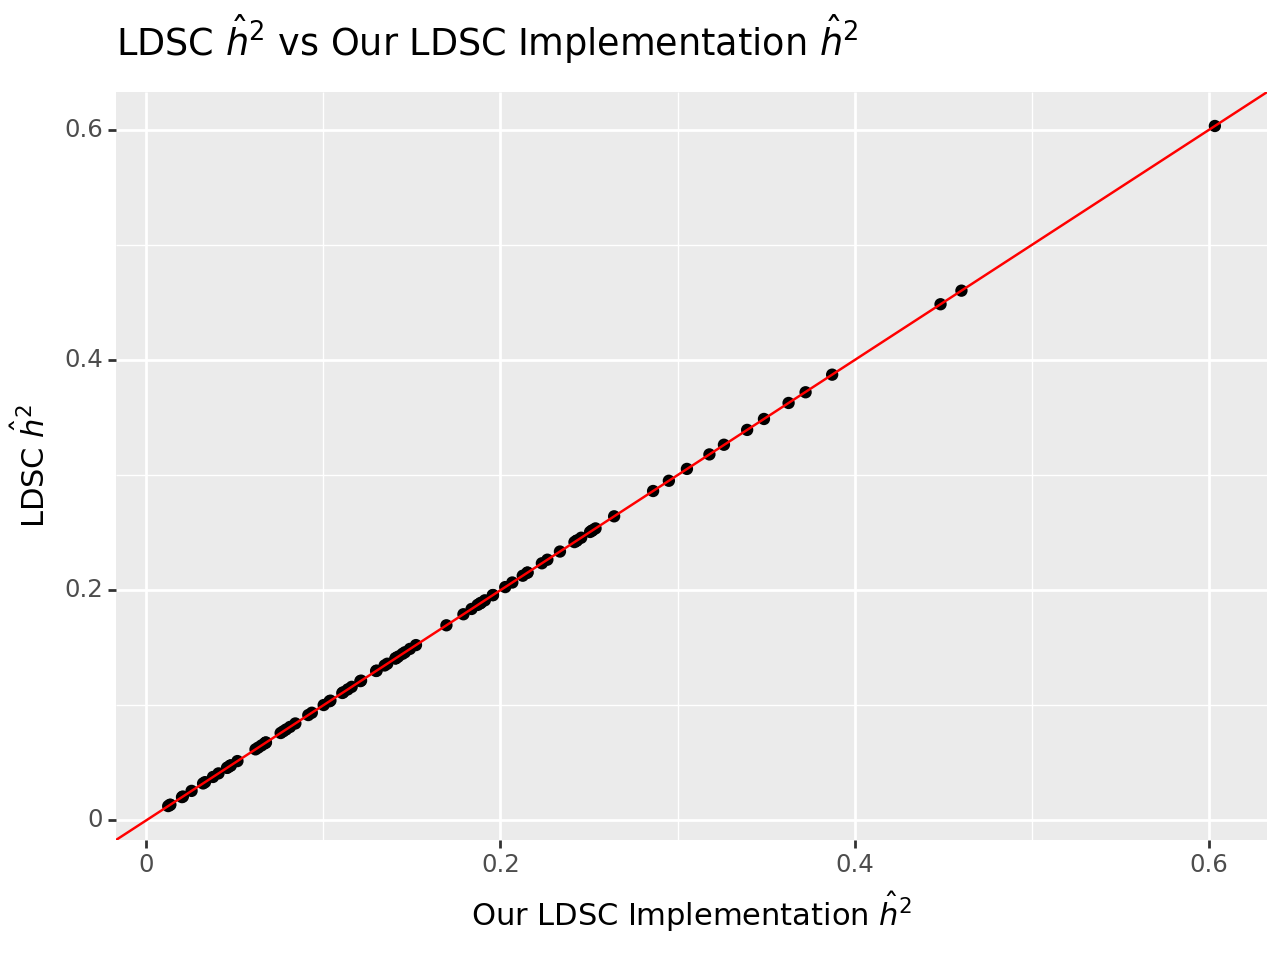

<Figure Size: (640 x 480)>

In [8]:
temp = res_free_intercept[['ldsc','ldsc_se','sstat']].reset_index(drop = True)
temp.columns = ['ldsc_h2_implementation','ldsc_se_implementation','sstat']
comp_df = ldsc_df.merge(temp)
# round to 3 decimal pts because the LDSC output rounds.

comp_df['ldsc_h2_implementation'] = np.float32(comp_df['ldsc_h2_implementation'])
comp_df['ldsc_se_implementation'] = np.float32(comp_df['ldsc_se_implementation'])

comp_df['ldsc_h2'] = np.float32(comp_df['ldsc_h2'])
comp_df['ldsc_se'] = np.float32(comp_df['ldsc_se'])

comp_df['ldsc_h2_implementation'] = np.round(comp_df['ldsc_h2_implementation'],4)
comp_df['ldsc_se_implementation'] = np.round(comp_df['ldsc_se_implementation'],4)

ggplot(comp_df,aes(x = 'ldsc_h2_implementation',y = 'ldsc_h2')) + geom_point() + geom_abline(slope = 1,color = 'red') + ggtitle(r'LDSC $\hat{h}^{2}$ vs Our LDSC Implementation $\hat{h}^{2}$') + xlab(r'Our LDSC Implementation $\hat{h}^{2}$') + ylab(r'LDSC $\hat{h}^{2}$')



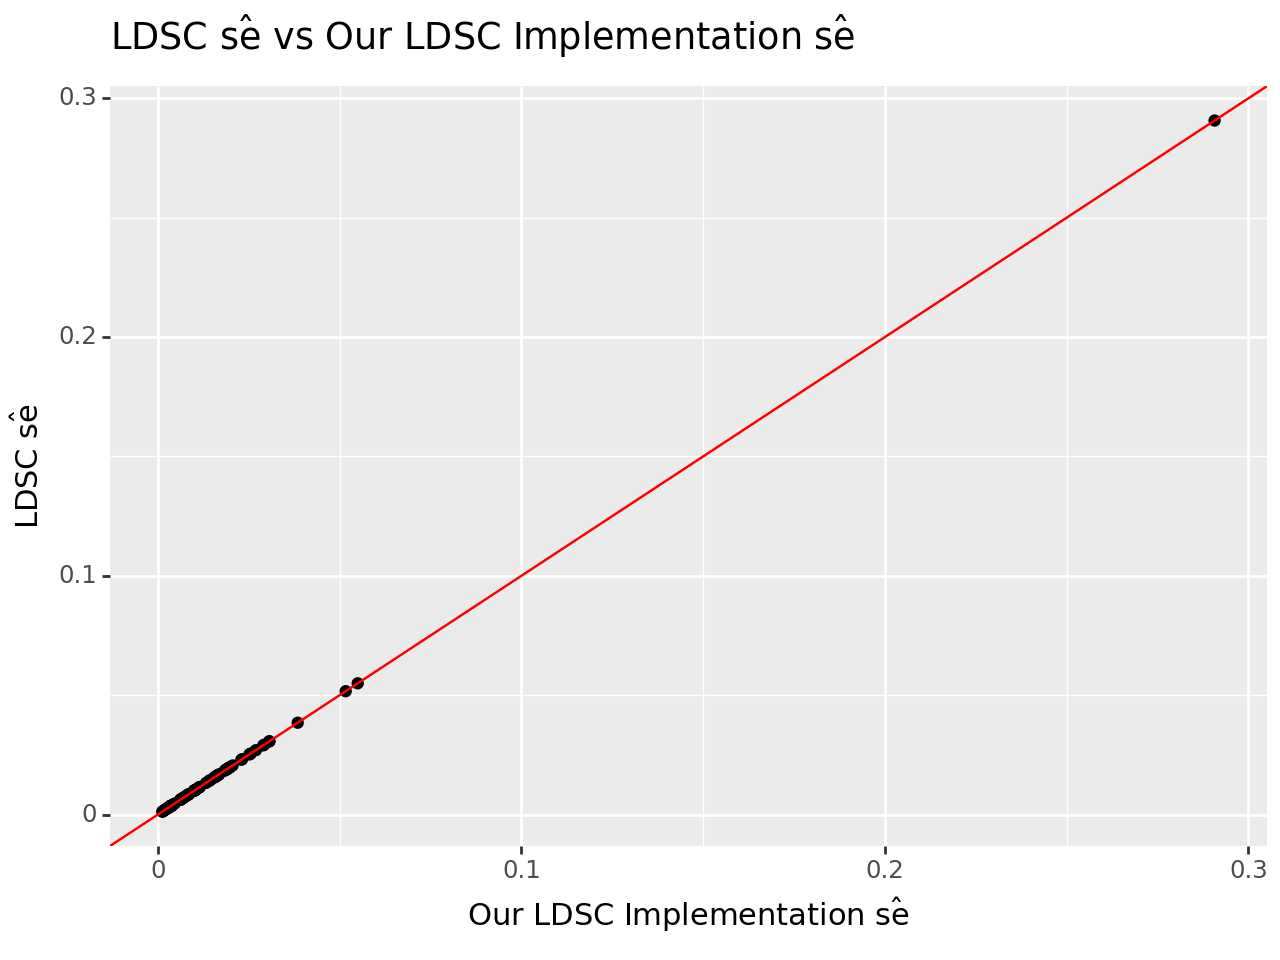

<Figure Size: (640 x 480)>

In [9]:
ggplot(comp_df,aes(x = 'ldsc_se_implementation',y = 'ldsc_se')) + geom_point() + geom_abline(slope = 1,color = 'red') + ggtitle(r'LDSC $\hat{\mathrm{se}}$ vs Our LDSC Implementation $\hat{\mathrm{se}}$') + xlab(r'Our LDSC Implementation $\hat{\mathrm{se}}$') + ylab(r'LDSC $\hat{\mathrm{se}}$')
